<a href="https://colab.research.google.com/github/Suharyanto-env/Sampah-Dumai/blob/main/Indeks_Sampah_Kec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# ==============================================================
#    STRUKTUR DAN KEMANDIRIAN PENGELOLAAN SAMPAH KECAMATAN
# ==============================================================

import pandas as pd
import matplotlib.pyplot as plt

In [27]:
# unduh dokumen dari google sheet
#CATATAN : 1) STATUS FILE : share everyone   2) Nama file yg dipakai ID nya (tengok di kolom link https nya)

url = "https://docs.google.com/spreadsheets/d/1UtPH4FheRLAYGKscK2Y-WjyqMbOVROjUaxkjZrg7Smw/export?format=csv"

df = pd.read_csv(url)

df

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,RT,Terolah,Reduksi,Liar,Hidden,Leaked
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,300,600,4000,3000,25230,28230
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,500,1000,4000,1000,12564,13564
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,100,800,4000,500,6152,6652
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,200,400,4000,3000,9750,12750
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,50,100,4000,1000,5050,6050
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,1000,6000,4000,2000,14600,16600
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,3000,13000,4000,3000,17940,20940


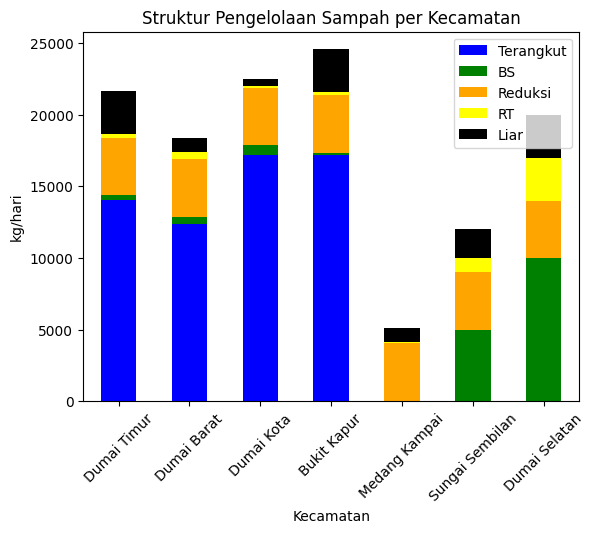

In [28]:
# pembuatan diagram batang struktur pengelolaan sampah per kecamatan
# ========================================================================

df_plot = df.set_index("Kecamatan")[["Terangkut","BS","Reduksi","RT","Liar"]]

df_plot.plot(kind="bar", stacked=True,
             color={"Terangkut":"blue",
             "BS":"green",
             "Reduksi":"orange",
             "RT":"yellow",
             "Liar":"black"})

plt.title("Struktur Pengelolaan Sampah per Kecamatan")

plt.ylabel("kg/hari")

plt.xticks(rotation=45)

plt.show()

# 📊 WLSRI (Waste Local Service Resilience Index)

## 1. Definisi

**WLSRI (Waste Local Service Resilience Index)** adalah indeks komposit yang digunakan untuk menilai tingkat **kemandirian dan ketahanan sistem pengelolaan sampah** di suatu wilayah (misalnya kecamatan).

Indeks ini menggambarkan kemampuan wilayah dalam:

* menangani sampah yang dihasilkan,
* mengurangi ketergantungan pada sistem eksternal,
* meminimalkan kebocoran sampah ke lingkungan.

---

## 2. Komponen Penyusun

WLSRI disusun dari 4 komponen utama:

### 1. SPI (Service Performance Index)

Menggambarkan tingkat pelayanan pengangkutan sampah.

[
SPI = {Terangkut} / {Timbulan}
]

---

### 2. Reduksi Ratio

Menggambarkan kemampuan pengurangan sampah dari sumber (misalnya bank sampah, komposting).

[
Reduksi Ratio = {Reduksi} / {Timbulan}
]

---

### 3. Terolah Ratio

Menggambarkan kemampuan pengolahan sampah di dalam sistem.

[
Terolah Ratio = {Terolah} / {Timbulan}
]

---

### 4. Leakage Index

Menggambarkan tingkat kebocoran sampah ke lingkungan.

[
Leakage\ Index = \frac{Sampah\ Tidak\ Terkelola}{Timbulan}
]

dimana:
[
Sampah\ Tidak\ Terkelola = Liar + RT + Hidden
]

---

## 3. Rumus WLSRI

[
WLSRI = (0.4 * SPI) + (0.2 * Reduksi Ratio) + (0.2 * Terolah Ratio) - (0.2 * Leakage Index)
]

---

## 4. Interpretasi Nilai

| Nilai WLSRI | Interpretasi                       |
| ----------- | ---------------------------------- |
| > 0.70      | Sistem sangat mandiri dan efektif  |
| 0.50 – 0.70 | Sistem cukup baik                  |
| 0.30 – 0.50 | Sistem sedang, perlu intervensi    |
| < 0.30      | Sistem lemah, prioritas penanganan |

---

## 5. Makna Analitis

WLSRI memberikan gambaran keseimbangan antara:

✔ **Kinerja pelayanan (SPI)**
✔ **Upaya pengurangan (Reduksi)**
✔ **Kapasitas pengolahan (Terolah)**
❌ **Kebocoran sistem (Leakage)**

Sehingga indeks ini dapat digunakan untuk:

* menentukan prioritas intervensi kebijakan,
* membandingkan kinerja antar kecamatan,
* mengidentifikasi titik lemah sistem pengelolaan sampah.

---

## 6. Catatan Penting

* Bobot (0.4, 0.2, 0.2, 0.2) dapat disesuaikan dengan kebijakan daerah.
* WLSRI bersifat **komparatif**, sehingga lebih kuat digunakan untuk perbandingan antar wilayah.
* Akurasi indeks sangat bergantung pada kualitas data timbulan dan pengelolaan.

---


In [29]:
# Nilai WRSRI
# ====================================================================
# perhitungan nilai SPI, Reduksi Ratio, Terolah Ratio, Leakage Index => nilai WLSRI

df['SPI'] = df['Terangkut'] / df['Timbulan']
df['Reduksi_Ratio'] = df['Reduksi'] / df['Timbulan']
df['Terolah_Ratio'] = df['Terolah'] / df['Timbulan']

df['un-Manage'] = df['Timbulan'] - (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Leakage_Index'] = df['un-Manage'] / df['Timbulan']

df['WLSRI'] = (
    0.4 * df['SPI'] +
    0.2 * df['Reduksi_Ratio'] +
    0.2 * df['Terolah_Ratio'] -
    0.2 * df['Leakage_Index']
)

df = df.sort_values(by='WLSRI', ascending=False)

df

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,RT,Terolah,Reduksi,Liar,Hidden,Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,un-Manage,Leakage_Index,WLSRI
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,100,800,4000,500,6152,6652,0.6,0.139714,0.027943,6652,0.232344,0.227063
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,200,400,4000,3000,9750,12750,0.5,0.116618,0.011662,12750,0.371720,0.151312
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,500,1000,4000,1000,12564,13564,0.4,0.129282,0.032321,13564,0.438397,0.104641
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,300,600,4000,3000,25230,28230,0.3,0.085288,0.012793,28230,0.601919,0.019232
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,3000,13000,4000,3000,17940,20940,0.0,0.105430,0.342646,20940,0.551924,-0.020770
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,50,100,4000,1000,5050,6050,0.0,0.394089,0.009852,6050,0.596059,-0.038424
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,1000,6000,4000,2000,14600,16600,0.0,0.150376,0.225564,16600,0.624060,-0.049624


In [30]:
# Tabel klasifikasi WLSRI antar kecamatan

def kategori(wlsri):
    if wlsri >= 0.6:
        return "Hijau (Baik)"
    elif wlsri >= 0.3:
        return "Kuning (Sedang)"
    else:
        return "Merah (Buruk)"

df['Kategori'] = df['WLSRI'].apply(kategori)

df

,No,Kecamatan,Penduduk,Rasio,Timbulan,% pelayanan,Terangkut,BS,RT,Terolah,...,Liar,Hidden,Leaked,SPI,Reduksi_Ratio,Terolah_Ratio,un-Manage,Leakage_Index,WLSRI,Kategori
2,3,Dumai Kota,40900,0.7,28630,60%,17178,700,100,800,...,500,6152,6652,0.6,0.139714,0.027943,6652,0.232344,0.227063,Merah (Buruk)
3,4,Bukit Kapur,49000,0.7,34300,50%,17150,200,200,400,...,3000,9750,12750,0.5,0.116618,0.011662,12750,0.371720,0.151312,Merah (Buruk)
1,2,Dumai Barat,44200,0.7,30940,40%,12376,500,500,1000,...,1000,12564,13564,0.4,0.129282,0.032321,13564,0.438397,0.104641,Merah (Buruk)
0,1,Dumai Timur,67000,0.7,46900,30%,14070,300,300,600,...,3000,25230,28230,0.3,0.085288,0.012793,28230,0.601919,0.019232,Merah (Buruk)
6,7,Dumai Selatan,54200,0.7,37940,0%,0,10000,3000,13000,...,3000,17940,20940,0.0,0.105430,0.342646,20940,0.551924,-0.020770,Merah (Buruk)
4,5,Medang Kampai,14500,0.7,10150,0%,0,50,50,100,...,1000,5050,6050,0.0,0.394089,0.009852,6050,0.596059,-0.038424,Merah (Buruk)
5,6,Sungai Sembilan,38000,0.7,26600,0%,0,5000,1000,6000,...,2000,14600,16600,0.0,0.150376,0.225564,16600,0.624060,-0.049624,Merah (Buruk)


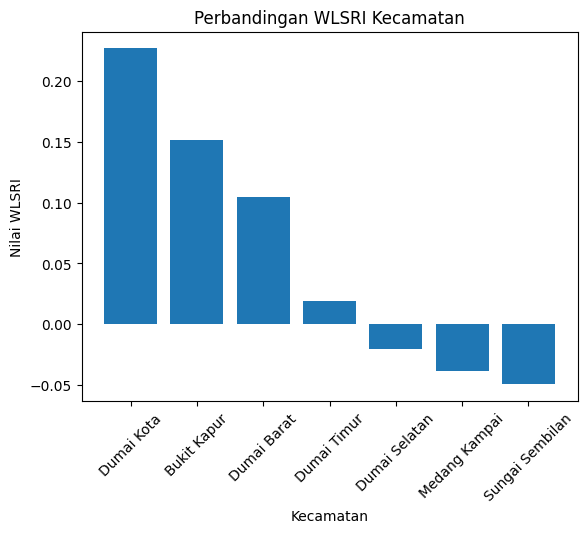

In [31]:
# Diagram batang perbandingan WLSRI antar kecamatan

plt.figure()
plt.bar(df['Kecamatan'], df['WLSRI'])
plt.xticks(rotation=45)
plt.title("Perbandingan WLSRI Kecamatan")
plt.xlabel("Kecamatan")
plt.ylabel("Nilai WLSRI")
plt.show()

In [ ]:
# Ranking WLSRI
df['Ranking'] = df['WLSRI'].rank(ascending=False, method='min')

# Urutkan
df = df.sort_values(by='WLSRI', ascending=False)

# Tampilkan inti perbandingan
df[['Kecamatan','WLSRI','Ranking']]

,Kecamatan,WLSRI,Ranking
2,Dumai Kota,0.227063,1.0
3,Bukit Kapur,0.151312,2.0
1,Dumai Barat,0.104641,3.0
0,Dumai Timur,0.019232,4.0
6,Dumai Selatan,-0.020770,5.0
4,Medang Kampai,-0.038424,6.0
5,Sungai Sembilan,-0.049624,7.0


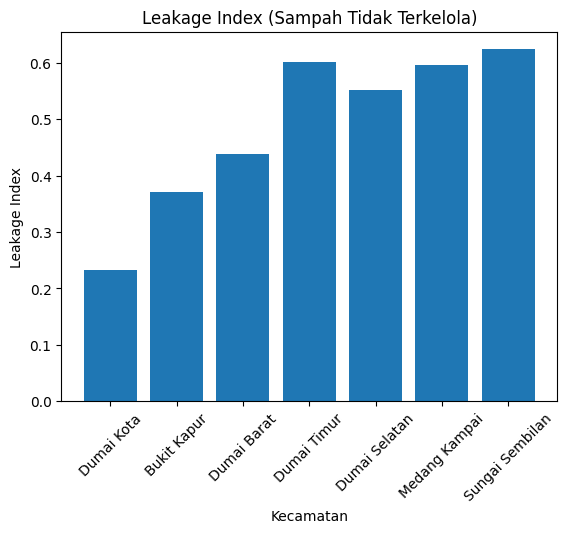

In [39]:
# Diagram Batang Leakage Index (sampah tidak terkelola)

plt.figure()
plt.bar(df['Kecamatan'], df['Leakage_Index'])
plt.xticks(rotation=45)
plt.title("Leakage Index (Sampah Tidak Terkelola)")
plt.xlabel("Kecamatan")
plt.ylabel("Leakage Index")
plt.show()

In [33]:
# Tabel Nilai WLSRI dan Kemandirian_Index
# =================================================================

df['Kemandirian_Index'] = (
    df['Reduksi'] + df['Terolah']
) / df['Timbulan']

df[["Kecamatan","WLSRI","Kemandirian_Index"]]

,Kecamatan,WLSRI,Kemandirian_Index
2,Dumai Kota,0.227063,0.167656
3,Bukit Kapur,0.151312,0.128280
1,Dumai Barat,0.104641,0.161603
0,Dumai Timur,0.019232,0.098081
6,Dumai Selatan,-0.020770,0.448076
4,Medang Kampai,-0.038424,0.403941
5,Sungai Sembilan,-0.049624,0.375940


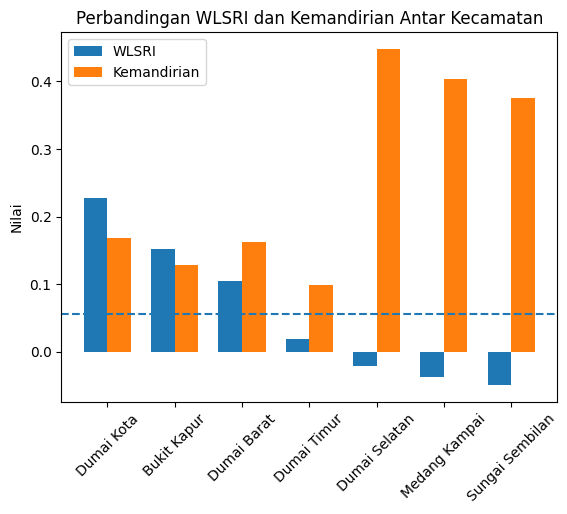

In [ ]:
# Diagram Batang Perbandingan WLSRI dan Kemandirian Index

import numpy as np

# pastikan sudah ada kolom ini
df['Kemandirian_Index'] = (df['Reduksi'] + df['Terolah']) / df['Timbulan']

# urutkan
df = df.sort_values(by='WLSRI', ascending=False)

x = np.arange(len(df))
width = 0.35

plt.figure()

plt.bar(x - width/2, df['WLSRI'], width, label='WLSRI')
plt.bar(x + width/2, df['Kemandirian_Index'], width, label='Kemandirian')

plt.xticks(x, df['Kecamatan'], rotation=45)
plt.ylabel("Nilai")
plt.title("Perbandingan WLSRI dan Kemandirian Antar Kecamatan")

plt.axhline(df['WLSRI'].mean(), linestyle='--')

plt.legend()
plt.show()

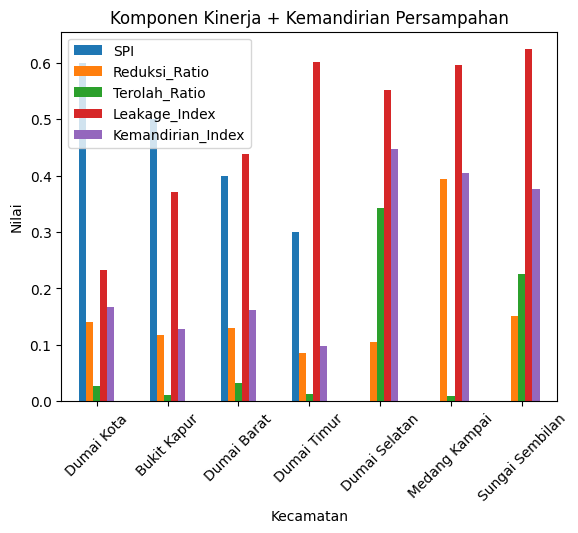

In [34]:
# Diagram Batang Struktur dan Kemandirian Pengelolaan Sampah

df_plot = df.set_index('Kecamatan')[[
    'SPI', 'Reduksi_Ratio', 'Terolah_Ratio',
    'Leakage_Index', 'Kemandirian_Index'
]]

df_plot.plot(kind='bar')
plt.title("Komponen Kinerja + Kemandirian Persampahan")
plt.xticks(rotation=45)
plt.ylabel("Nilai")
plt.show()

In [45]:
# ANALISIS
# ===========================================================================

# Validasi dasar
df['Total_Terkelola'] = (
    df['Terangkut'] + df['Terolah'] + df['Reduksi']
)

df['Tidak_Terkelola'] = df['Timbulan'] - df['Total_Terkelola']

# Flag masalah
def cek_valid(row):
    if row['Tidak_Terkelola'] < 0:
        return "ERROR DATA (double counting)"
    elif row['Tidak_Terkelola'] > 0.3 * row['Timbulan']:
        return "KEBOCORAN TINGGI"   # 30% dari timbulan sampah tidak terkelola
    else:
        return "Sampah Terkelola"

df['%Leakage'] = df['Tidak_Terkelola'] / df['Timbulan'] * 100

df['Status_Data'] = df.apply(cek_valid, axis=1)

df[['Kecamatan','Tidak_Terkelola','%Leakage','Status_Data']]

,Kecamatan,Tidak_Terkelola,%Leakage,Status_Data
2,Dumai Kota,6652,23.234370,Sampah Terkelola
3,Bukit Kapur,12750,37.172012,KEBOCORAN TINGGI
1,Dumai Barat,13564,43.839690,KEBOCORAN TINGGI
0,Dumai Timur,28230,60.191898,KEBOCORAN TINGGI
6,Dumai Selatan,20940,55.192409,KEBOCORAN TINGGI
4,Medang Kampai,6050,59.605911,KEBOCORAN TINGGI
5,Sungai Sembilan,16600,62.406015,KEBOCORAN TINGGI
